# Chapter 11 — Symmetry suffices

*Companion notebook to **The Learned Kernel**, Ch. 11. Run top to bottom.*

A table such as Taiwan Credit is **unordered**. Two facts follow that the modeling does not
impose: the rows are **exchangeable** (relabeling leaves the joint law unchanged), and
**similarity is symmetric** (how much row *i* resembles *j* does not depend on which is the
query). A permutation-invariant operator over exchangeable rows factors through a symmetric
statistic, so the Gram is symmetric. Bochner (Ch. 8) closes the loop: the symmetric stationary
class already contains every stationary geometry, so committing to symmetry loses no
expressivity. Asymmetry is **extra capacity**; on an exchangeable table it has nothing to
represent and must be learned away at a cost.

**The frame** — *what is learned · how scored · what you read off.*
What: the pairwise *k(x,x')* and its antisymmetric **directional content** Δ = k − kᵀ.
Scored: the first-order change in held-out risk along k_s + εΔ is **−2⟨Δ, h_a⟩**, with the
response gradient h_a(x,x') = m(x) − m(x'). Read off: the alignment ⟨Δ, h_a⟩ and the predictive
gain *D* — near zero on an exchangeable table, large on a directed task.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from lkbook import set_style
from lkbook.chapters import ch11

set_style()

## 11.1  The head-to-head on Taiwan Credit

Two attention smoothers, identical encoder / schedule / Nadaraya–Watson readout, differing in
**one** thing: the symmetric form **shares** the projection (W_Q = W_K, a PSD Gram — the one-line
"linear-attention" retrofit), the asymmetric form keeps **separate** W_Q, W_K. If symmetry costs
nothing, the symmetric model should match the asymmetric one — at fewer parameters.

In [3]:
tw = ch11.run_taiwan_headtohead()
print(f"asymmetric (W_Q != W_K): AUC {tw['asym'].mean():.3f} +/- {tw['asym'].std():.3f}"
      f"   ({tw['n_params']['asym']} params)")
print(f"symmetric  (shared W)  : AUC {tw['sym'].mean():.3f} +/- {tw['sym'].std():.3f}"
      f"   ({tw['n_params']['sym']} params)")
print("=> matched held-out AUC; the symmetric model uses ~30% fewer parameters.")

asymmetric (W_Q != W_K): AUC 0.647 +/- 0.017   (880 params)
symmetric  (shared W)  : AUC 0.651 +/- 0.017   (624 params)
=> matched held-out AUC; the symmetric model uses ~30% fewer parameters.


## 11.2  The first-order law: gain is proportional to −⟨Δ, h_a⟩

Any pairwise score splits into symmetric + antisymmetric parts under the swap x↔x'. The
directional content Δ = k − kᵀ does predictive work only insofar as it aligns with the response
gradient h_a. The theorem: the first-order risk change along k_s + εΔ is −2⟨Δ, h_a⟩, so the gain
**vanishes exactly when Δ ⊥ h_a**. We sweep a family of directions whose alignment ranges over an
interval and check the measured risk derivative tracks −⟨Δ, h_a⟩.

In [4]:
law = ch11.run_first_order()
print(f"corr( <Delta, h_a> , measured dL/deps ) = {law['corr']:+.3f}   (the law predicts ~ -1)")
print("=> the gain is proportional to -<Delta, h_a> and passes through the origin.")

corr( <Delta, h_a> , measured dL/deps ) = -0.983   (the law predicts ~ -1)
=> the gain is proportional to -<Delta, h_a> and passes through the origin.


## 11.3  On exchangeable data the directional content is orthogonal to the signal

On Taiwan Credit, ⟨Δ, h_a⟩ over **random** admissible antisymmetric directions concentrates at
zero: a generic asymmetric kernel's directional content is orthogonal-in-expectation to the
response gradient, so it buys nothing to first order.

In [5]:
ortho = ch11.run_orthogonality()
ti = ortho["taiwan_ips"]
print(f"Taiwan <Delta,h_a> over random directions: mean {ti.mean():+.4f}, std {ti.std():.4f}"
      f"  (|mean|/std = {abs(ti.mean())/ti.std():.2f})")
print(f"directed-task aligned <Delta,h_a> = {ortho['directed_aligned']:+.3f}"
      f"  (vs random std {ortho['directed_random_std']:.3f}) — far off zero")

Taiwan <Delta,h_a> over random directions: mean +0.0005, std 0.0029  (|mean|/std = 0.19)
directed-task aligned <Delta,h_a> = +0.272  (vs random std 0.102) — far off zero


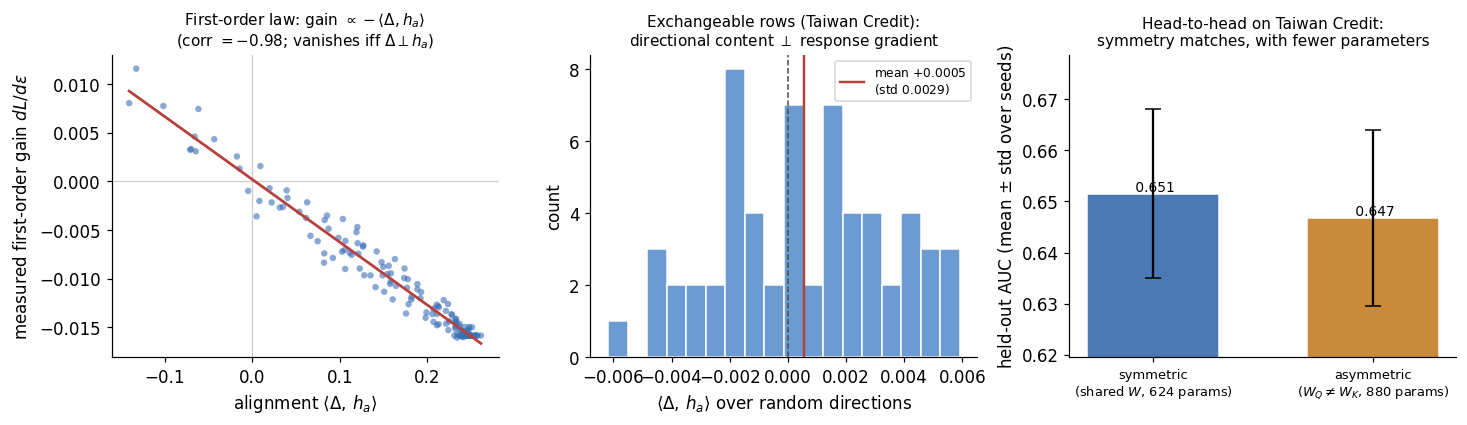

In [6]:
ch11.make_law_figure({"law": law, "ortho": ortho, "taiwan": tw})
plt.show()

## 11.4  When asymmetry is earned: a directed task

Asymmetry pays exactly when an admissible antisymmetric direction aligns with h_a — when the data
carries a **directed** relation. Construct one: each point has a position, the support label is a
smooth signal s(pos), and the query target is the **lagged** signal s(pos − δ). Predicting the
target requires attending *upstream* by a fixed offset, which a symmetric distance kernel (centered
at the query's own position) cannot do.

In [7]:
di = ch11.run_directed_headtohead()
print(f"directed lag task — asymmetric RMSE {di['asym'].mean():.3f}, "
      f"symmetric RMSE {di['sym'].mean():.3f}")
print(f"audit gain D (symmetrizing the trained asym model) median {np.median(di['D']):+.1f}"
      f"  — symmetrizing destroys the learned lag")

directed lag task — asymmetric RMSE 0.213, symmetric RMSE 0.729
audit gain D (symmetrizing the trained asym model) median +23.9  — symmetrizing destroys the learned lag


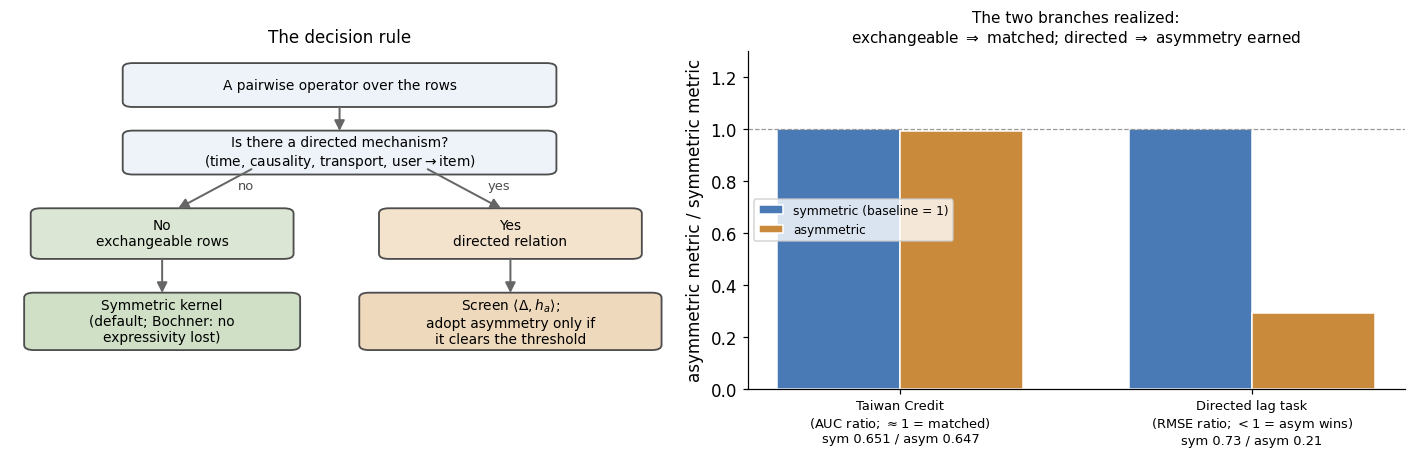

In [8]:
ch11.make_decision_figure(di, tw)
plt.show()

## 11.5  Explore: how directed must the data be before asymmetry is earned?

Sweep the lag δ. At δ = 0 the task is undirected and the two models match; as δ grows the
symmetric kernel, forced to center its weight at the query's own position, falls behind while the
asymmetric kernel tracks the offset. The screen ⟨Δ, h_a⟩ rises off zero in step.

In [9]:
from ipywidgets import interact, FloatSlider


def compare_at_lag(lag=0.18):
    r = ch11.directed_one_lag(lag, seed=0)
    fig, ax = plt.subplots(figsize=(5.6, 4.0), constrained_layout=True)
    ax.bar([0, 1], [r["sym"], r["asym"]], width=0.6,
           color=["#4a7ab5", "#c98a3b"], edgecolor="white")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["symmetric", "asymmetric"])
    ax.set_ylabel("held-out RMSE"); ax.set_ylim(0, max(r.values()) * 1.2 + 1e-3)
    for x, v in zip([0, 1], [r["sym"], r["asym"]]):
        ax.text(x, v, f" {v:.3f}", ha="center", va="bottom", fontsize=9)
    verdict = "matched (undirected)" if r["sym"] - r["asym"] < 0.05 else "asymmetry earned"
    ax.set_title(f"lag delta = {lag:.2f}: {verdict}", fontsize=10)
    plt.show()


interact(compare_at_lag, lag=FloatSlider(min=0.0, max=0.30, step=0.03, value=0.18,
         description="lag"));

interactive(children=(FloatSlider(value=0.18, description='lag', max=0.3, step=0.03), Output()), _dom_classes=…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the symmetric model is not merely smaller but **matched**. Compute the
per-seed AUC gap (asymmetric − symmetric) and check its mean is within seed noise of zero.

In [10]:
# TODO: use tw["asym"] and tw["sym"] to compute the per-seed gap and its mean/std
gap = None
print(gap)

None


<details><summary>Solution</summary>

```python
gap = tw["asym"] - tw["sym"]
print(f"mean gap {gap.mean():+.4f} +/- {gap.std():.4f}")  # ~0 within noise
```
The asymmetric parameterization carries more parameters but returns no held-out accuracy for
them: the extra antisymmetric capacity is orthogonal to the response gradient on exchangeable
rows, so symmetrizing loses nothing.
</details>

**(⋆)** Show the orthogonality is a property of the **data**, not the direction. Take the directed
task's *aligned* direction and confirm ⟨Δ, h_a⟩ is large there, then confirm a *random* direction
on the same data is near zero — the alignment, not the asymmetry, is what matters.

In [11]:
# TODO: print ortho["directed_aligned"] and ortho["directed_random_std"] and compare
ratio = None
print(ratio)

None


<details><summary>Solution</summary>

```python
ratio = abs(ortho["directed_aligned"]) / ortho["directed_random_std"]
print(f"aligned / random-spread = {ratio:.1f}")   # >> 1: the aligned direction is special
```
A random antisymmetric direction is orthogonal-in-expectation to h_a even on directed data; only
the direction aligned with the directed mechanism (the positional offset) carries ⟨Δ, h_a⟩ ≠ 0.
Asymmetry is earned by alignment with a directed relation, not by asymmetry per se.
</details>

---
*Companion to Chapter 11 of **The Learned Kernel**. Everything here comes from
`lkbook.chapters.ch11` — the same code the book's figures come from. The head-to-head trains two
attention smoothers differing only in symmetry; the first-order law and orthogonality are computed
in closed form on the running example; the directed lag task is the one regime where asymmetry is
earned. The larger study (sixty-cell audit, head-to-head against standard self-attention, TabPFN
reverse-engineering) is summarized in the book and in
`similarity-hierarchy-research/affinity/symmetric_kernels_tabular.tex`.*